## **DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS**

**📌 Objective**
* The goal of this project is to analyze Blinkit sales data and uncover insights about product performance, outlet characteristics, and customer buying patterns using Exploratory Data Analysis (EDA).

## **Import Libraries**

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## **Import Raw Data**

In [54]:
df = pd.read_csv(r"C:\Users\YAMINI2528\Downloads\blinkit_data.csv")

## **Sample Data**

In [55]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [56]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


## **Size of Data**

In [57]:
df.shape

(8523, 12)

In [62]:
print("Size of Data :", df.shape)

Size of Data : (8523, 12)


## **Field info**

In [63]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

## **Data type**

In [64]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

## **Data cleaning**

In [68]:
# Check missing values
df.isnull().sum()

# Fill missing values (example)
df['Item Weight'].fillna(df['Item Weight'].mean(), inplace=True)
df['Outlet Size'].fillna(df['Outlet Size'].mode()[0], inplace=True)

# Check duplicates
df.duplicated().sum()

C:\Users\YAMINI2528\AppData\Local\Temp\ipykernel_15552\3032106815.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item Weight'].fillna(df['Item Weight'].mean(), inplace=True)
C:\Users\YAMINI2528\AppData\Local\Temp\ipykernel_15552\3032106815.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

0

In [69]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [70]:
df['Item Fat Content'] = df['Item Fat Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'lf': 'Low Fat',
    'reg': 'Regular',
    'Regular': 'Regular',
    'Low fat': 'Low Fat',
    'Lf': 'Low Fat'
})


In [50]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


## **Feature Understanding** ##

## 📊 Dataset Features

- Item Type: Category of product  
- Fat Content: Low Fat / Regular  
- Outlet Size: Small / Medium / High  
- Outlet Location Type: Tier 1 / Tier 2 / Tier 3  
- Sales: Target variable (revenue)

## **BUSINESS REQUIRMENTS**

## **KPI's REQUIREMENTS**

In [73]:
#total sales
total_sales = df['Sales'].sum()

#Average sales
avg_sales = df['Sales'].mean()

#no of Items sold
no_of_items_sold = df['Sales'].count()

#Average Ratings
avg_ratings = df['Rating'].mean()

#Display
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.1f}")
print(f"No of Items Sold: ${no_of_items_sold:,.0f}")
print(f"Average rating: ${avg_ratings:,.1f}")


Total Sales: $1,201,681
Average Sales: $141.0
No of Items Sold: $8,523
Average rating: $4.0


## **CHARTS REQUIREMENTS** ##

## **Univariate Analysis**

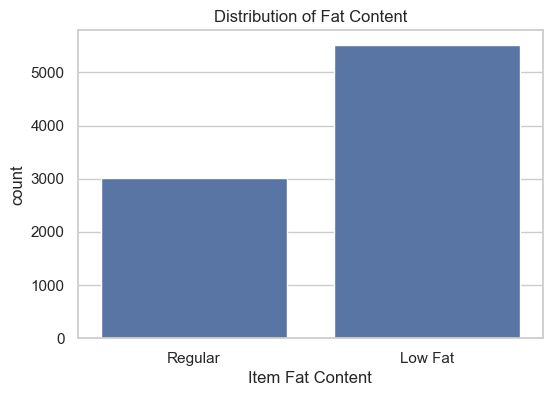

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x='Item Fat Content', data=df)
plt.title("Distribution of Fat Content")
plt.show()

**📌 Insight:**

* Low fat products appear more frequently, indicating higher demand.

## **Total Sales by Fat Content**

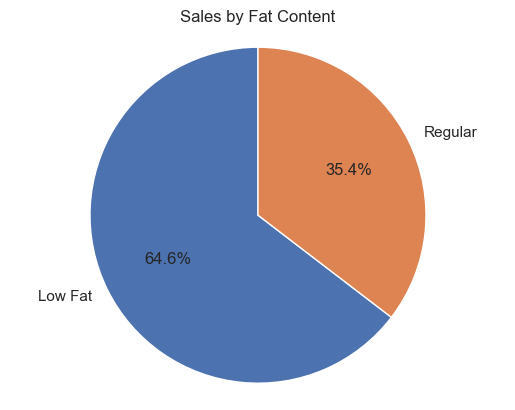

In [75]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat, labels= sales_by_fat.index,
                      autopct = '%.1f%%',
                      startangle = 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

**📌 Insight:**

* Low fat products contribute more to overall sales compared to regular fat products, indicating a higher customer preference for healthier options.

## **Total Sales by Item Type**

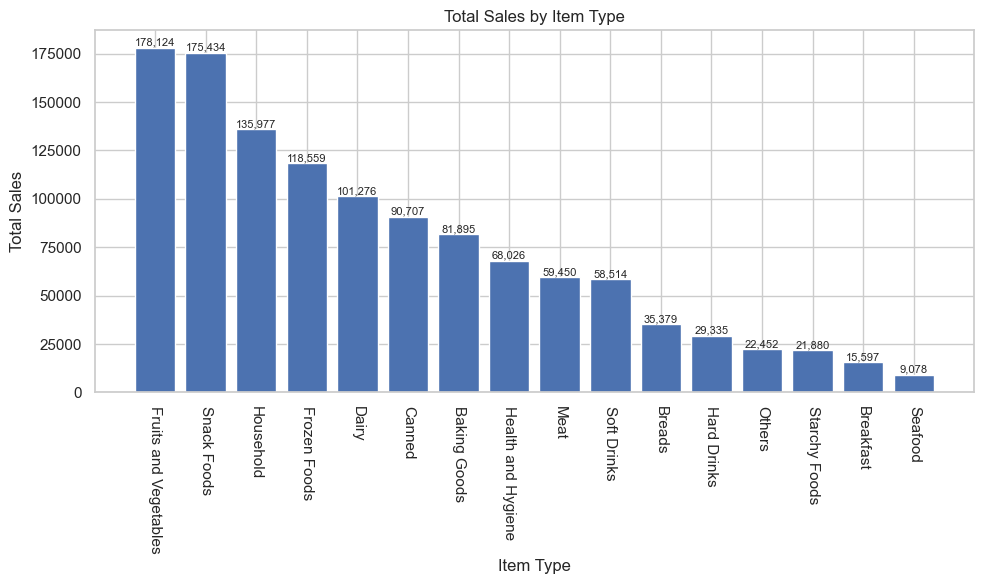

In [76]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=-90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**📌 Insight:**

* Certain categories like snacks and dairy contribute more to total sales.

## **Fat Content by Outlet for Total Sales**

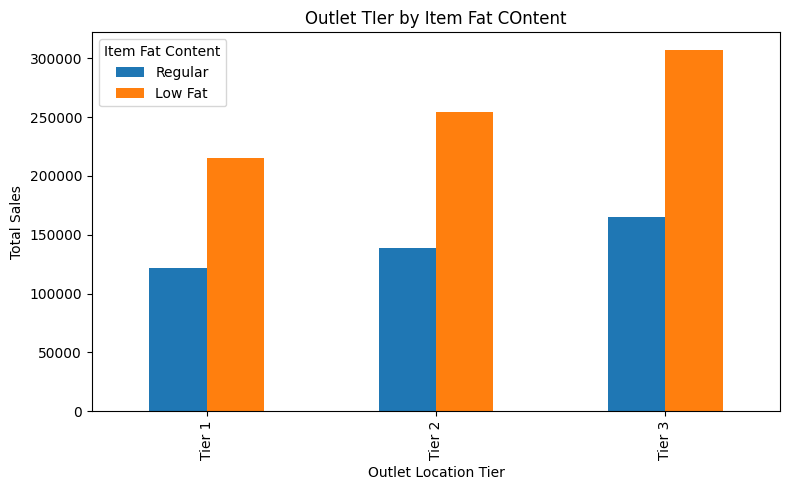

In [ ]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet TIer by Item Fat COntent')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

## **Total Sales by Outlet Establishment**

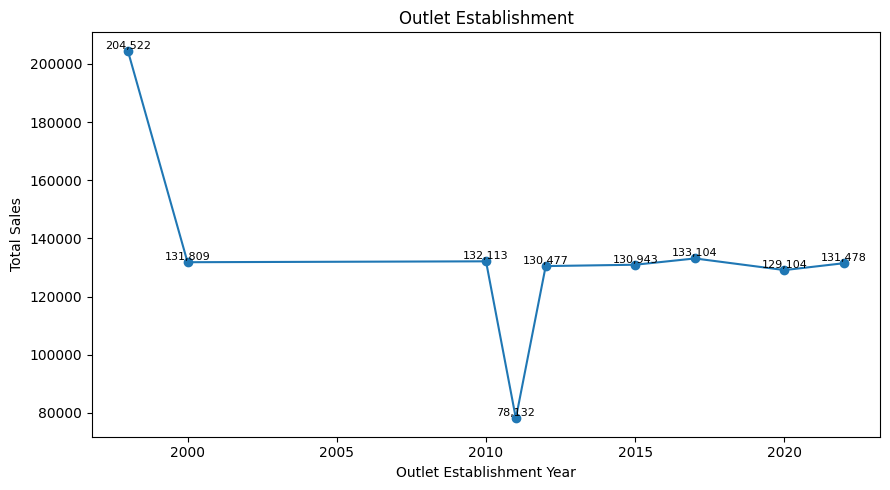

In [ ]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**📌 Insight:**

* Older outlets tend to have higher sales, which may be due to customer trust, brand recognition, and established presence.

## **Sales by Outlet Size**

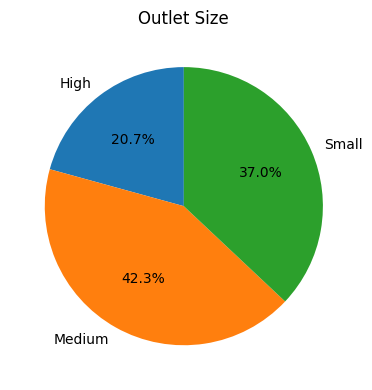

In [ ]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4, 4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

**📌 Insight:**

* Medium-sized outlets generate higher sales compared to small and high outlets, indicating optimal performance at moderate scale.

## **Sales by Outlet Location**

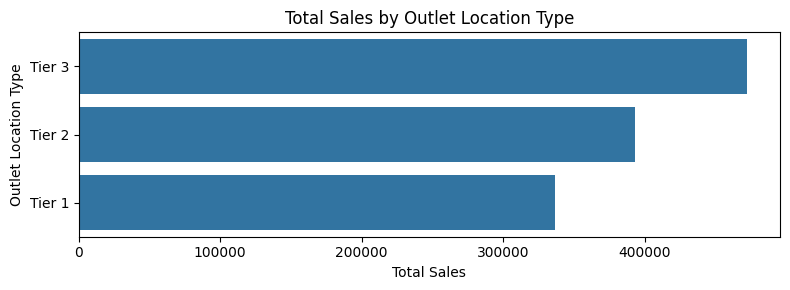

In [ ]:
sales_by_location = df.groupby('Outlet Location Type') ['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 3)) # Smaller height, enough width
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout() #Ensures Layout fits without scroll
plt.show()

**📌 Insight:**

* Tier 3 locations generate higher sales compared to Tier 1 and Tier 2.
* Tier 3 locations contribute the highest sales, suggesting that smaller cities or developing areas have strong customer demand.

## **Correlation Heatmap**

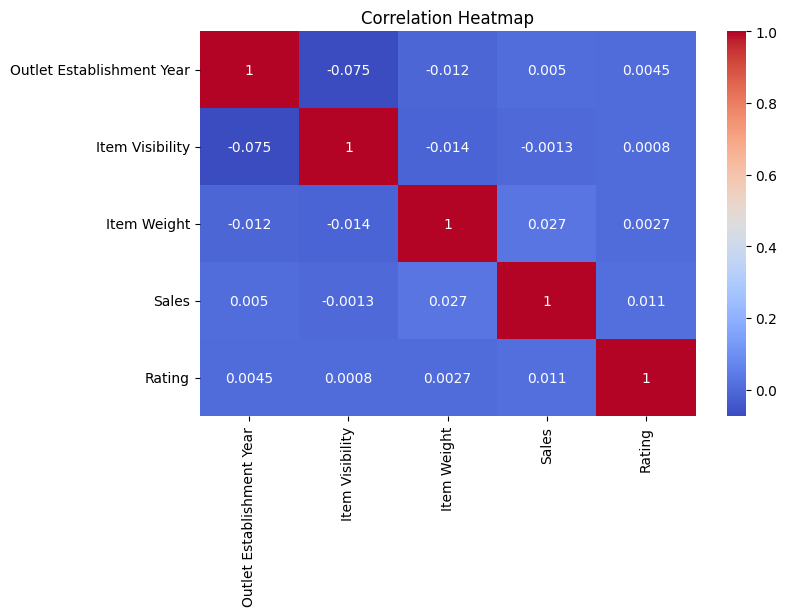

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**📌 Insight:**

* There is no strong correlation between most numerical features and sales, indicating that multiple factors collectively influence revenue.

## 🔍 Key Insights

- Low fat products are more popular among customers  
- Tier 3 cities contribute significantly to overall sales  
- Medium-sized outlets generate higher revenue  
- Certain product categories dominate sales performance  

## 💡 Business Recommendations

- Focus more on high-performing product categories  
- Expand operations in Tier 3 cities  
- Increase stock for low-fat products  
- Optimize medium-sized outlet operations for better efficiency  

## ✅ Conclusion
This analysis helped understand sales patterns and business performance, which can support better decision-making.